In [1]:
from util import *
from preprocessor import DataPreProcessor
from trainer import QuantumGraphTrainer
from evaluator import Evaluator

In [2]:
filename = '../../data/processed_data_graph_10_(2, 3, 2)_1000.csv'
data_type = "graph"  # Change to "graph" or "freq" as needed.
n_qubits = 4  # Must be provided for conversion.

processor = DataPreProcessor(filename, data_type=data_type, n_qubits=n_qubits)
converted_data = processor.convert_data()

if data_type == "graph":
    # Print the first 3 PyTorch Geometric Data objects.
    for data_obj in converted_data[:3]:
        print(data_obj)
elif data_type == "cnn":
    # Print the first 2 CNN entries.
    for entry in converted_data[:2]:
        print("CNN tensor shape:", entry["cnn"].shape)
        print("Noisy:", entry["noisy"])
        print("Ideal:", entry["ideal"])
        print("ZNE:", entry["zne"])
else:
    X, Y = converted_data
    print("Feature shape:", X.shape)
    print("Target shape:", Y.shape)

Data(x=[206], edge_index=[2], y=-1.0, richardson_zne=-0.62451171875, ideal=-1.0, mlp_features=[2], noisy=-0.46533203125, linear_zne=-0.5874837040901184)
Data(x=[285], edge_index=[2], y=-8.901751293812371e-33, richardson_zne=-0.004638671875, ideal=-8.901751293812371e-33, mlp_features=[2], noisy=0.01123046875, linear_zne=0.00439453125)
Data(x=[320], edge_index=[2], y=1.0, richardson_zne=0.769287109375, ideal=1.0, mlp_features=[2], noisy=0.375, linear_zne=0.5066731572151184)


Epoch 01, Loss: 0.0899
Epoch 02, Loss: 0.0081
Epoch 03, Loss: 0.0071
Epoch 04, Loss: 0.0066
Epoch 05, Loss: 0.0075
Epoch 06, Loss: 0.0073
Epoch 07, Loss: 0.0064
Epoch 08, Loss: 0.0038
Epoch 09, Loss: 0.0051
Epoch 10, Loss: 0.0050
Epoch 11, Loss: 0.0047
Epoch 12, Loss: 0.0038
Epoch 13, Loss: 0.0043
Epoch 14, Loss: 0.0043
Epoch 15, Loss: 0.0043
Epoch 16, Loss: 0.0048
Epoch 17, Loss: 0.0040
Epoch 18, Loss: 0.0045
Epoch 19, Loss: 0.0037
Epoch 20, Loss: 0.0048
Epoch 21, Loss: 0.0053
Epoch 22, Loss: 0.0044
Epoch 23, Loss: 0.0033
Epoch 24, Loss: 0.0039
Epoch 25, Loss: 0.0045
Epoch 26, Loss: 0.0040
Epoch 27, Loss: 0.0039
Epoch 28, Loss: 0.0049
Epoch 29, Loss: 0.0042
Epoch 30, Loss: 0.0031
Epoch 31, Loss: 0.0042
Epoch 32, Loss: 0.0042
Epoch 33, Loss: 0.0041
Epoch 34, Loss: 0.0041
Epoch 35, Loss: 0.0041
Epoch 36, Loss: 0.0034
Epoch 37, Loss: 0.0034
Epoch 38, Loss: 0.0034
Epoch 39, Loss: 0.0041
Epoch 40, Loss: 0.0039
Epoch 41, Loss: 0.0039
Epoch 42, Loss: 0.0040
Epoch 43, Loss: 0.0045
Epoch 44, L

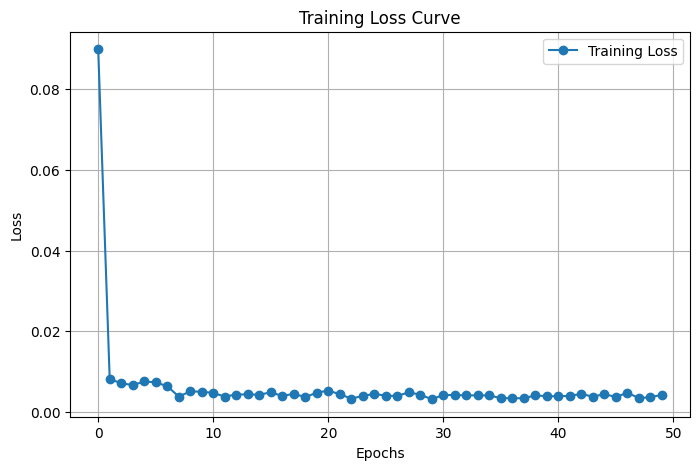

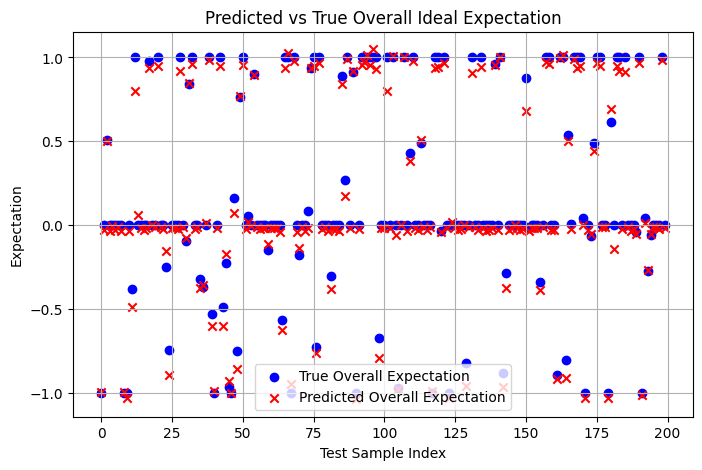

In [3]:
trainer = QuantumGraphTrainer(
            data_list=converted_data,
            n_qubits=5,
            hidden_channels=32,
            mlp_hidden=16,
            batch_size=2,
            lr=0.01,
            epochs=50,
            test_size=0.2,
            mult_mlp=1,
            mult_graph=1
        )
trainer.train()
trainer.plot_results()

In [4]:
pred, targ = trainer.evaluate()

Error Metrics:
Method: Noisy
  MSE: 0.111995
  RMSE: 0.334656
  MAE: 0.223887

Method: Linear
  MSE: 0.070794
  RMSE: 0.266072
  MAE: 0.180314

Method: Richardson
  MSE: 0.047699
  RMSE: 0.218400
  MAE: 0.159778

Method: Predicted
  MSE: 0.002484
  RMSE: 0.049844
  MAE: 0.035627



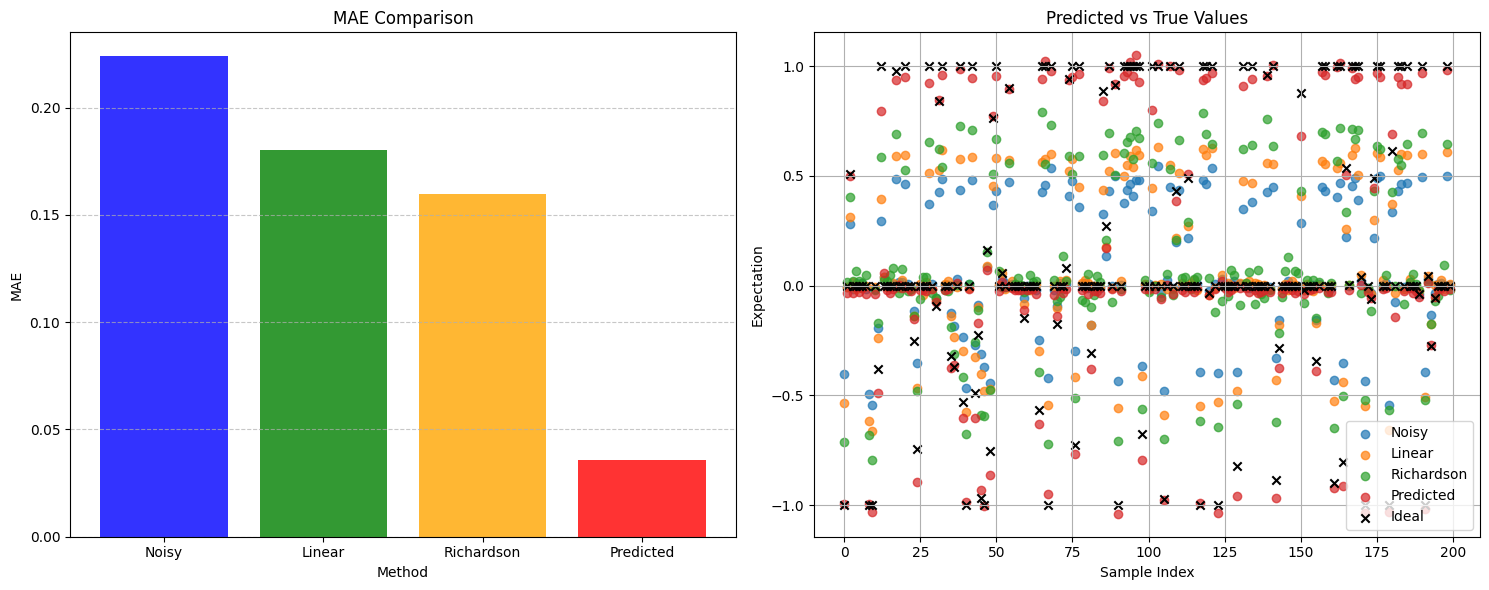

In [5]:
evaluator = Evaluator(pred, targ, trainer.test_loader.dataset)
    
evaluator.print_metrics()
    
evaluator.plot_error_metrics(error_metric='MAE')

Best hyperparameters (nqbit: 4, depth: 10): {'hidden_channels': 122, 'mlp_hidden': 79, 'batch_size': 157, 'lr': 0.00554518377130505, 'epochs': 494, 'test_size': 0.10322970409774476, 'mult_noisy': 0.4617498988308998, 'mult_pauli': 0.3920959851959027, 'mult_mlp': 0.693777354316808, 'mult_graph': 1.2089394962945295}

## Tuning

### Optuna

In [ ]:
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error

def objective(trial):
    """Optimization target function for quantum-graph neural network tuning"""
    params = {
        'hidden_channels': trial.suggest_int("hidden_channels", 16, 256),
        'mlp_hidden': trial.suggest_int("mlp_hidden", 8, 128),
        'batch_size': trial.suggest_int("batch_size", 16, 256),
        'lr': trial.suggest_float("lr", 1e-5, 1e-1, log=True),
        'epochs': trial.suggest_int("epochs", 50, 500),
        'mult_pauli': trial.suggest_float("mult_pauli", 0.1, 2.0),
        'mult_graph': trial.suggest_float("mult_graph", 0.1, 2.0)
    }

    trainer = QuantumGraphTrainer(
        converted_data,
        n_qubits=n_qubits,
        test_size=0.2,
        **params
    )
    
    trainer.train()
    pred, targ = trainer.evaluate()
    return np.sqrt(mean_squared_error(targ.flatten(), pred.flatten()))

# Create named study with optimization settings
study = optuna.create_study(
    study_name="Hybrid GNN Tuner",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study.optimize(objective, n_trials=50, gc_after_trial=True)

# Save optimization results
study.trials_dataframe().to_csv("hybrid_gnn_tuning_results.csv")

print(f"Best trial for {study.study_name}:")
print(f"RMSE: {study.best_value:.4f}")
print("Optimal parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


## Performance

In [ ]:
# Initialize and run the trainer.
trainer = QuantumGraphTrainer(converted_data, n_qubits=n_qubits, test_size=0.2, **study.best_params)
trainer.train()
# trainer.plot_results()
pred, targ = trainer.evaluate()

In [ ]:
evaluator = Evaluator(pred, targ, trainer.test_loader.dataset)
    
evaluator.print_metrics()
    
# Plot box plots for error metrics for each method (combined over samples).
# # Here, we only have one scalar per sample, so box plots will show distribution of errors.
evaluator.plot_error_metrics(error_metric='MAE')
# # Plot predictions vs. ideal values.
evaluator.plot_results()